In [1]:
import sys
sys.path.append("../src")

In [2]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

from qibo import Circuit

# ------------------------------------------------------------
# Classical transforms
# ------------------------------------------------------------

from hybridqsp.transforms import (
    hadamard_transform_2d,
    inverse_hadamard_transform_2d,
)

# ------------------------------------------------------------
# Thresholding
# ------------------------------------------------------------

from hybridqsp.thresholding import top_k_threshold

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

from hybridqsp.metrics import (
    state_fidelity,
    trace_distance,
)

# ------------------------------------------------------------
# Quantum transforms
# ------------------------------------------------------------

from hybridqsp.quantum.qdct import qdct

## Load Cameraman image

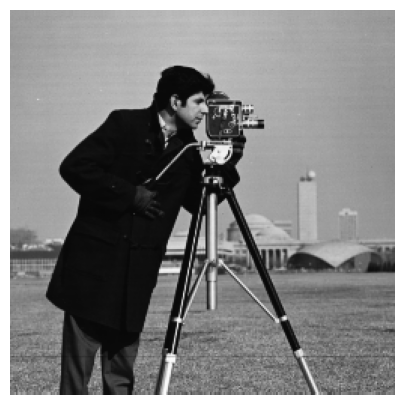

In [3]:
img = plt.imread("../dataset/cameraman.tiff")
plt.figure(figsize=(5, 5))
plt.imshow(img, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
plt.show()

## Select a random 8×8 block 

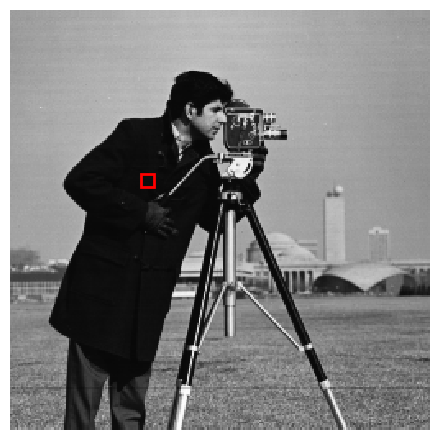

In [4]:
row = 100
col = 80

block = img[row:row+8, col:col+8]

# ------------------------------------------------------------
# Display image and selected block
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(4.5, 4.5))

ax.imshow(
    img,
    cmap="gray",
    interpolation="nearest",
    vmin=0,
    vmax=255
)

ax.add_patch(
    Rectangle(
        (col - 0.5, row - 0.5),
        8,
        8,
        edgecolor="red",
        linewidth=2,
        facecolor="none"
    )
)

ax.axis("off")

plt.tight_layout()

plt.show()

DS-QSP Experiment (Hadamard)
Block size         : 8 × 8
State dimension    : 64
Amplitude qubits   : 6
Retained coeffs    : 6


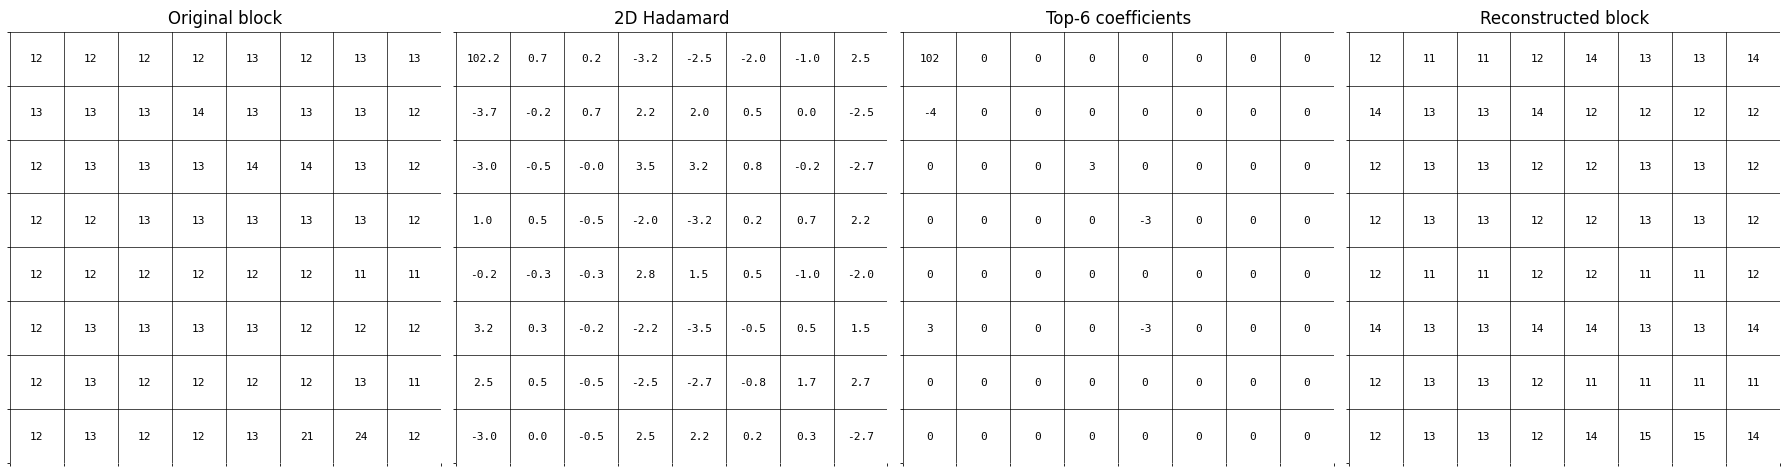

In [5]:
# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------
block_size = 8             
k_keep = 6                 # retained Hadamard coefficients

# ------------------------------------------------------------
# Derived quantities
# ------------------------------------------------------------

dimension = block_size ** 2
nqubits = int(np.log2(dimension))

assert 2 ** nqubits == dimension, \
    "block_size must satisfy block_size^2 = 2^n."

assert 1 <= k_keep <= dimension, \
    "Invalid number of retained coefficients."

print("=" * 45)
print("DS-QSP Experiment (Hadamard)")
print("=" * 45)
print(f"Block size         : {block_size} × {block_size}")
print(f"State dimension    : {dimension}")
print(f"Amplitude qubits   : {nqubits}")
print(f"Retained coeffs    : {k_keep}")
print("=" * 45)

# ------------------------------------------------------------
# Extract block
# ------------------------------------------------------------

block = img[
    row:row + block_size,
    col:col + block_size
]

# ------------------------------------------------------------
# Classical DS-QSP pipeline
# ------------------------------------------------------------

b_had = hadamard_transform_2d(block)

xt = top_k_threshold(
    b_had,
    k_keep
)

x_recons = inverse_hadamard_transform_2d(xt)

# ------------------------------------------------------------
# Plot helper
# ------------------------------------------------------------

def draw_matrix(ax, matrix, decimals=None):

    N = matrix.shape[0]

    ax.imshow(
        np.ones((N, N)),
        cmap="gray",
        interpolation="nearest",
        vmin=0,
        vmax=1
    )

    ax.set_xticks(np.arange(-0.5, N, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, N, 1), minor=True)

    ax.grid(
        which="minor",
        color="black",
        linewidth=0.5
    )

    ax.set_xticks([])
    ax.set_yticks([])

    fontsize = max(3, int(70 / N))

    for i in range(N):
        for j in range(N):

            value = matrix[i, j]

            if decimals is None:
                text = f"{int(np.round(value))}"
            else:
                text = f"{value:.{decimals}f}"

            ax.text(
                j,
                i,
                text,
                ha="center",
                va="center",
                fontsize=fontsize,
                family="monospace"
            )

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_xlim(-0.5, N - 0.5)
    ax.set_ylim(N - 0.5, -0.5)
    ax.set_aspect("equal")

# ------------------------------------------------------------
# Plot classical pipeline
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    4,
    figsize=(18, 4.8)
)

titles = [
    "Original block",
    "2D Hadamard",
    f"Top-{k_keep} coefficients",
    "Reconstructed block"
]

matrices = [
    block,
    b_had,
    np.round(xt),
    np.round(x_recons)
]

decimals = [
    None,
    1,
    None,
    None
]

for ax, title, M, d in zip(
    axes,
    titles,
    matrices,
    decimals
):
    draw_matrix(ax, M, decimals=d)
    ax.set_title(title, fontsize=12)

plt.tight_layout()
plt.show()

## Qibo Implementation 

In [21]:
from qibo import Circuit, gates
from qibo.models.encodings import sparse_encoder
from qibo.ui import plot_circuit

In [22]:
# ------------------------------------------------------------
# Normalize states
# ------------------------------------------------------------

target_state = block.flatten().astype(float)
target_state /= np.linalg.norm(target_state)

compressed_state = xt.flatten().astype(float)
x_norm = compressed_state/np.linalg.norm(compressed_state)

Circuit depth = 29
Total number of gates = 51
Number of qubits = 6
Most common gates:
cx: 20
x: 16
ry: 9
h: 6
None


(<Axes: >, <Figure size 360x360 with 1 Axes>)

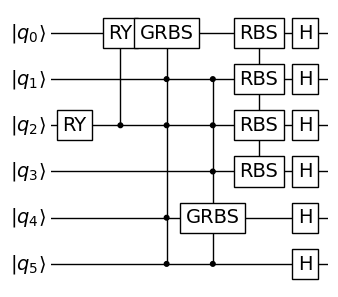

In [23]:
# Sparse transform-domain coefficient vector
vec = x_norm

# Indices of nonzero coefficients
nz = np.flatnonzero(vec)

# Total number of qubits required
# for amplitude encoding
nqubits = int(np.log2(len(vec)))

# Construct sparse basis-state representation
# as (bitstring, amplitude) pairs
y = [
    (format(i, f"0{nqubits}b"), vec[i])
    for i in nz
]

# Prepare sparse quantum state using
# the Farias SQSP method
qc = sparse_encoder(
    y,
    method="farias"
)


for i in range(6):
    qc.add(gates.H(i))

# Display decomposed circuit statistics
# for quantum resource analysis
print(qc.decompose().decompose().decompose().summary())
plot_circuit(qc)

In [34]:
final_state = np.real(qc().state())

td = trace_distance(final_state, target_state)

print(td)

0.10951929825267252
